In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready!")

Environment ready!


In [21]:
import pandas as pd

df = pd.read_csv("solar-energy-consumption.csv")

df.head()

,Entity,Code,Year,Solar
0,ASEAN (Ember),NaN,2000,0.0
1,ASEAN (Ember),NaN,2001,0.0
2,ASEAN (Ember),NaN,2002,0.0
3,ASEAN (Ember),NaN,2003,0.0
4,ASEAN (Ember),NaN,2004,0.0


In [22]:
print("Shape:", df.shape)

df.info()

Shape: (9486, 4)
<class 'pandas.DataFrame'>
RangeIndex: 9486 entries, 0 to 9485
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Entity  9486 non-null   str    
 1   Code    8395 non-null   str    
 2   Year    9486 non-null   int64  
 3   Solar   9486 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 296.6 KB


In [23]:
df["Entity"].unique()[:20]

<StringArray>
[      'ASEAN (Ember)',         'Afghanistan',              'Africa',
         'Africa (EI)',      'Africa (Ember)',             'Albania',
             'Algeria',      'American Samoa',              'Angola',
 'Antigua and Barbuda',           'Argentina',             'Armenia',
               'Aruba',                'Asia',        'Asia (Ember)',
   'Asia Pacific (EI)',           'Australia',             'Austria',
          'Azerbaijan',             'Bahamas']
Length: 20, dtype: str

In [24]:
print("Earliest year:", df["Year"].min())
print("Latest year:", df["Year"].max())

Earliest year: 1965
Latest year: 2025


In [25]:
clean_df = df.dropna(subset=["Code"])

In [26]:
clean_df["Entity"].nunique()

228

In [27]:
clean_df[clean_df["Entity"] == "Ghana"].head()

,Entity,Code,Year,Solar
3366,Ghana,GHA,2000,0.0
3367,Ghana,GHA,2001,0.0
3368,Ghana,GHA,2002,0.0
3369,Ghana,GHA,2003,0.0
3370,Ghana,GHA,2004,0.0


In [28]:
african_countries = [
    "Algeria","Angola","Benin","Botswana","Burkina Faso","Burundi",
    "Cameroon","Cape Verde","Central African Republic","Chad","Comoros",
    "Congo","Democratic Republic of Congo","Djibouti","Egypt",
    "Equatorial Guinea","Eritrea","Eswatini","Ethiopia","Gabon",
    "Gambia","Ghana","Guinea","Guinea-Bissau","Ivory Coast",
    "Kenya","Lesotho","Liberia","Libya","Madagascar","Malawi",
    "Mali","Mauritania","Mauritius","Morocco","Mozambique",
    "Namibia","Niger","Nigeria","Rwanda","Sao Tome and Principe",
    "Senegal","Seychelles","Sierra Leone","Somalia","South Africa",
    "South Sudan","Sudan","Tanzania","Togo","Tunisia","Uganda",
    "Zambia","Zimbabwe"
]

africa_df = clean_df[clean_df["Entity"].isin(african_countries)]

print("Rows:", africa_df.shape[0])
print("Countries:", africa_df["Entity"].nunique())

Rows: 1396
Countries: 53


## How has solar energy consumption evolved across Africa over time?

In [29]:
africa_trend = africa_df.groupby("Year")["Solar"].sum().reset_index()

africa_trend.head()

,Year,Solar
0,1965,0.0
1,1966,0.0
2,1967,0.0
3,1968,0.0
4,1969,0.0


#### Aggregation by Year

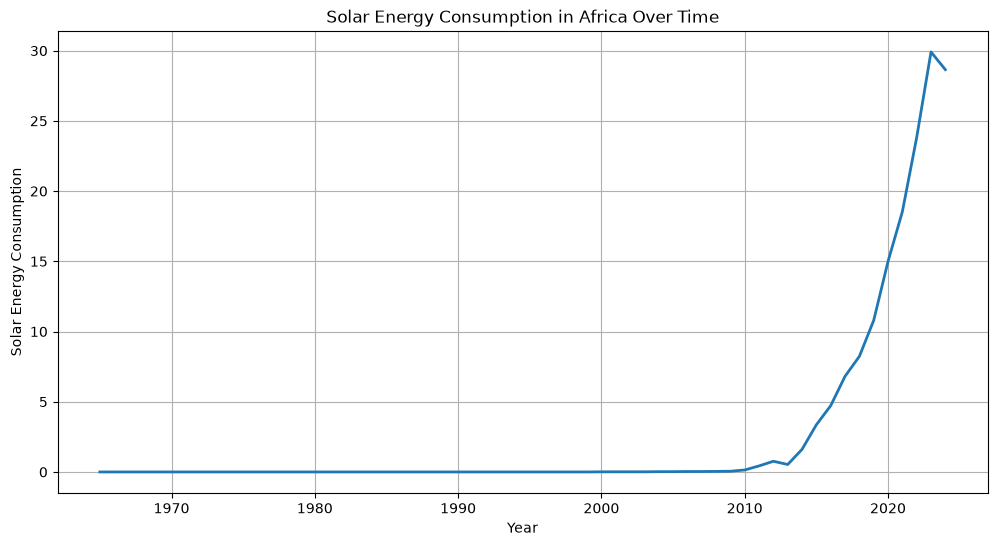

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    africa_trend["Year"],
    africa_trend["Solar"],
    linewidth=2
)

plt.title("Solar Energy Consumption in Africa Over Time")
plt.xlabel("Year")
plt.ylabel("Solar Energy Consumption")
plt.grid(True)

plt.show()

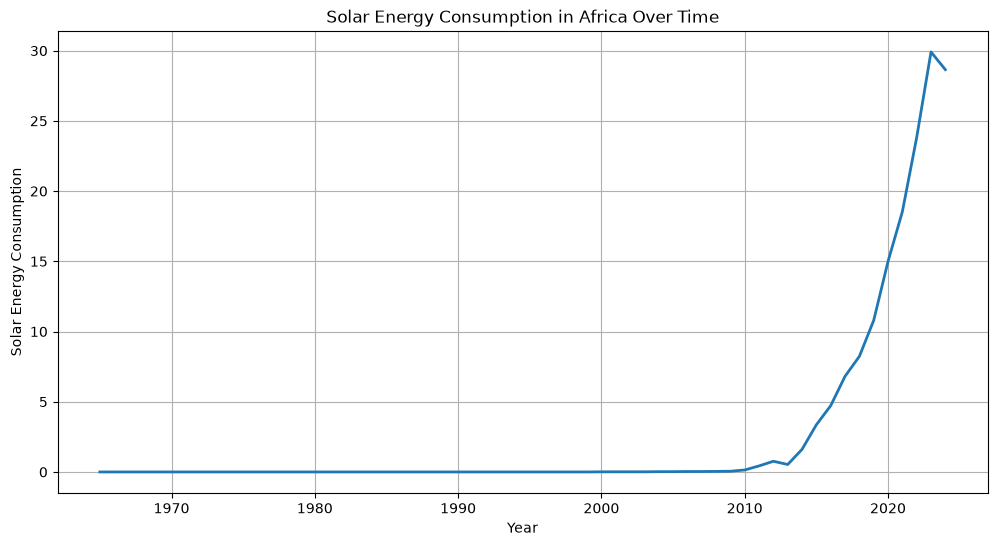

In [31]:
plt.figure(figsize=(12,6))

plt.plot(
    africa_trend["Year"],
    africa_trend["Solar"],
    linewidth=2
)

plt.title("Solar Energy Consumption in Africa Over Time")
plt.xlabel("Year")
plt.ylabel("Solar Energy Consumption")
plt.grid(True)

plt.savefig("africa_solar_trend.png", dpi=300, bbox_inches="tight")

plt.show()

## Key Finding

Solar energy consumption across Africa remained negligible ie zero until 2010. Growth accelerated after 2015 and increased rapidly after 2020, reflecting expanding renewable-energy deployment, access to solar technologies, favourable renewable energy policies, declining solar PV costs and increasing investment in solar technologies across the continent.

## Top 10 African Countries by Solar Energy Consumption

In [32]:
top_countries = (
    africa_df.groupby("Entity")["Solar"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries

Entity
South Africa                    79.43
Egypt                           29.27
Morocco                         11.83
Algeria                          5.43
Democratic Republic of Congo     5.41
Namibia                          2.79
Senegal                          2.78
Kenya                            2.27
Tunisia                          2.21
Angola                           0.98
Name: Solar, dtype: float64

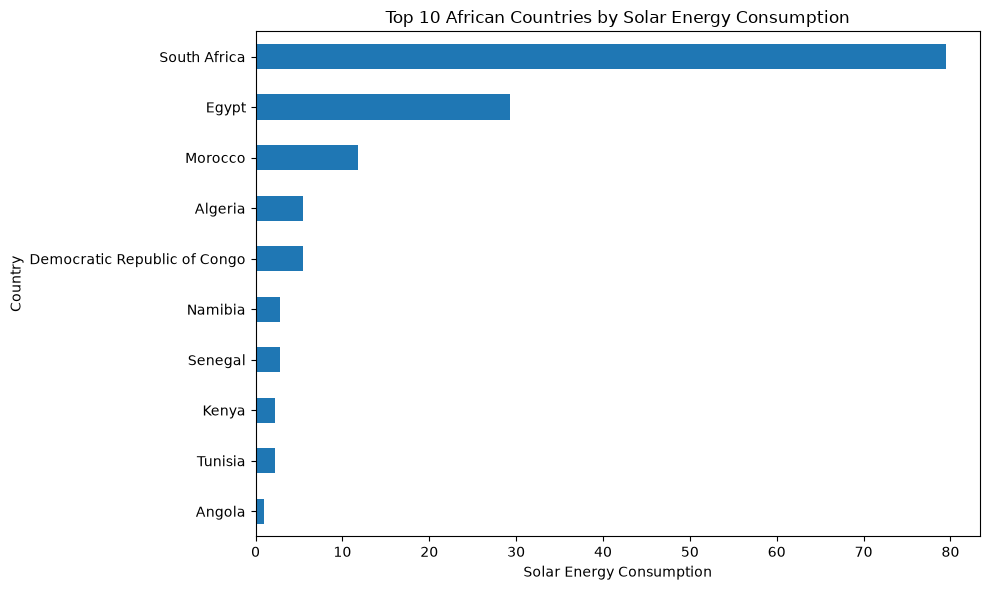

In [33]:
import matplotlib.pyplot as plt

top_countries = (
    africa_df.groupby("Entity")["Solar"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 African Countries by Solar Energy Consumption")
plt.xlabel("Solar Energy Consumption")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [34]:
latest_year = africa_df["Year"].max()

latest_data = africa_df[africa_df["Year"] == latest_year]

latest_data.sort_values(
    by="Solar",
    ascending=False
).head(10)

,Entity,Code,Year,Solar
7804,South Africa,ZAF,2024,19.85
2575,Egypt,EGY,2024,6.07
5671,Morocco,MAR,2024,1.59
4532,Kenya,KEN,2024,0.55
8607,Tunisia,TUN,2024,0.49
6008,Nigeria,NGA,2024,0.10


In [35]:
latest_data[latest_data["Entity"] == "Ghana"]

,Entity,Code,Year,Solar


In [36]:
africa_df[africa_df["Entity"] == "Ghana"].tail()

,Entity,Code,Year,Solar
3385,Ghana,GHA,2019,0.05
3386,Ghana,GHA,2020,0.06
3387,Ghana,GHA,2021,0.13
3388,Ghana,GHA,2022,0.16
3389,Ghana,GHA,2023,0.15


## GHANA in view

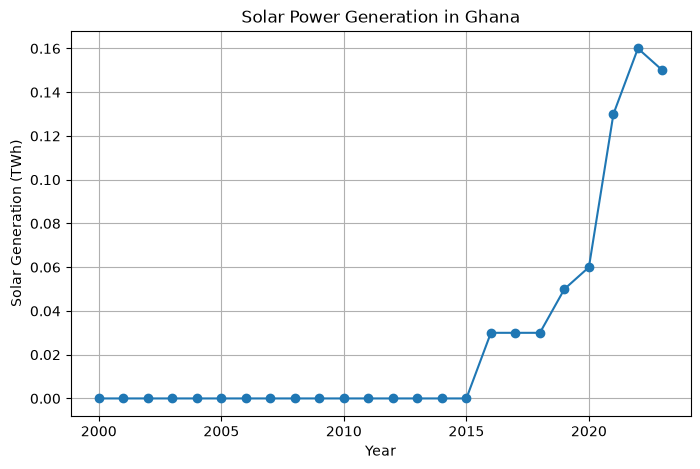

In [37]:
import matplotlib.pyplot as plt

ghana = africa_df[
    africa_df["Entity"] == "Ghana"
]

plt.figure(figsize=(8,5))
plt.plot(ghana["Year"], ghana["Solar"], marker="o")
plt.title("Solar Power Generation in Ghana")
plt.xlabel("Year")
plt.ylabel("Solar Generation (TWh)")
plt.grid(True)
plt.show()

### Top 10 African Solar Producers (2024)

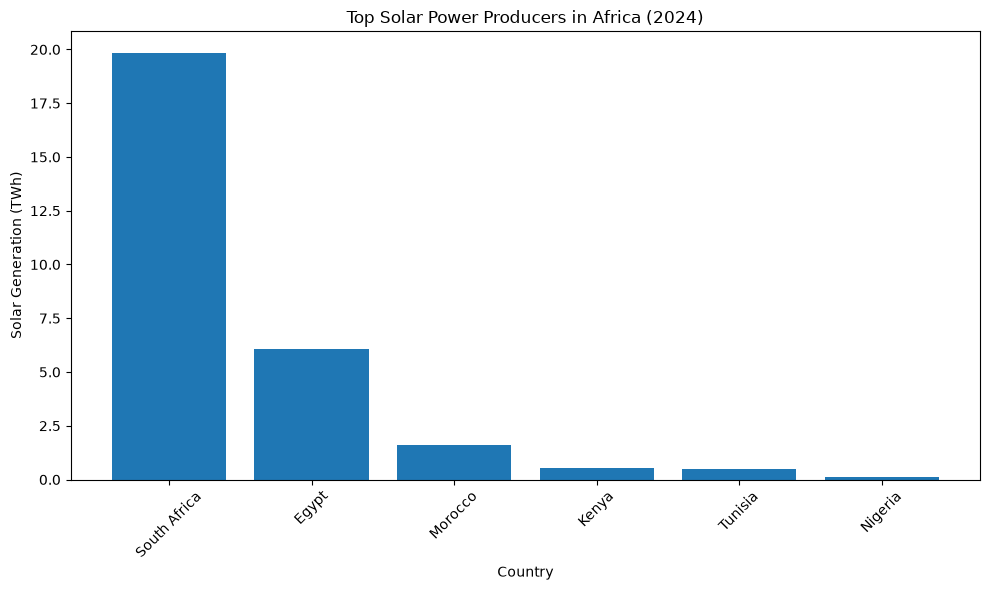

In [45]:
import matplotlib.pyplot as plt

top10 = latest_data.sort_values(
    by="Solar",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10["Entity"], top10["Solar"])
plt.title("Top Solar Power Producers in Africa (2024)")
plt.xlabel("Country")
plt.ylabel("Solar Generation (TWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "images/top_solar_producers.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Ghana Solar Generation Trend

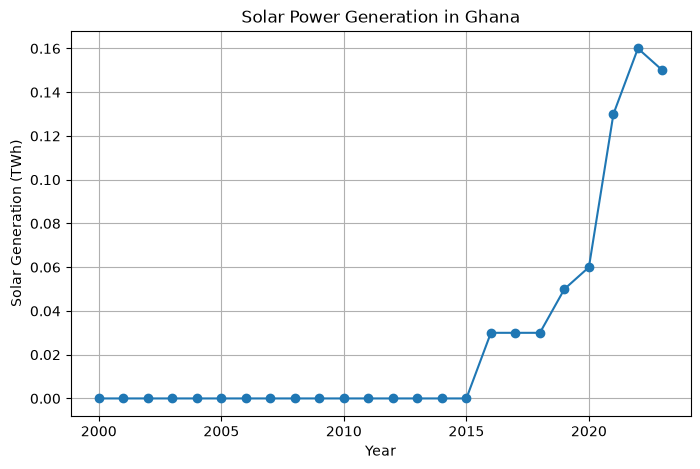

In [44]:
ghana = africa_df[africa_df["Entity"]=="Ghana"]

plt.figure(figsize=(8,5))
plt.plot(
    ghana["Year"],
    ghana["Solar"],
    marker="o"
)

plt.title("Solar Power Generation in Ghana")
plt.xlabel("Year")
plt.ylabel("Solar Generation (TWh)")
plt.grid(True)
plt.savefig(
    "images/solar_generation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Compare Ghana, South Africa and Egypt

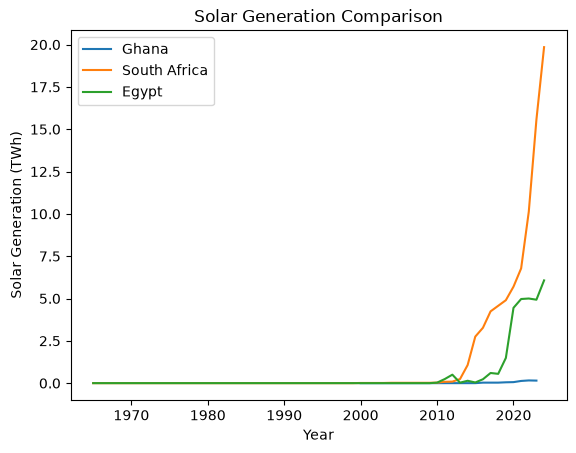

In [43]:
countries = ["Ghana","South Africa","Egypt"]

comparison = africa_df[
    africa_df["Entity"].isin(countries)
]

for country in countries:
    temp = comparison[
        comparison["Entity"] == country
    ]

    plt.plot(
        temp["Year"],
        temp["Solar"],
        label=country
    )

plt.legend()
plt.title("Solar Generation Comparison")
plt.xlabel("Year")
plt.ylabel("Solar Generation (TWh)")
plt.savefig(
    "images/solar_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()